In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement et nettoyage
df = pd.read_csv('C:/Users/hp/Desktop/DI_BOOTCAMP/week2/day4/dailyChallenge/Sample - Superstore.csv', encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Sales'] = pd.to_numeric(df['Sales'])
df['Profit'] = pd.to_numeric(df['Profit'])
df['Discount'] = pd.to_numeric(df['Discount'])


<IPython.core.display.Javascript object>


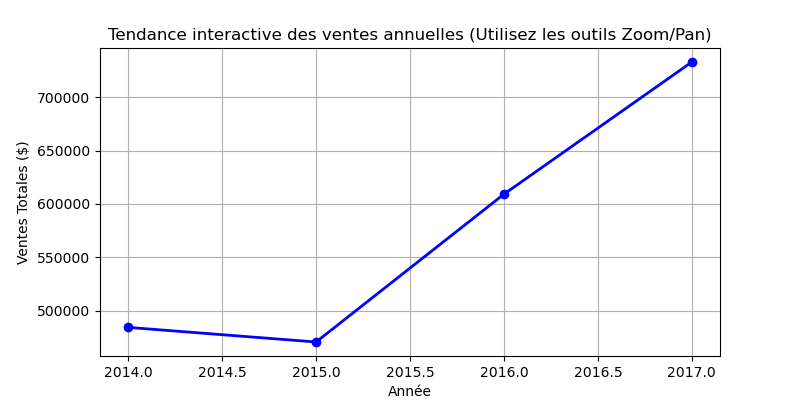

In [2]:
# Activer l'interactivité dans Jupyter (Zoom, Panoramique, Sauvegarde)
%matplotlib notebook

# Agrégation des ventes par année
sales_years = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 4))
plt.plot(sales_years['Year'], sales_years['Sales'], marker='o', color='b', linewidth=2)
plt.title("Tendance interactive des ventes annuelles (Utilisez les outils Zoom/Pan)")
plt.xlabel("Année")
plt.ylabel("Ventes Totales ($)")
plt.grid(True)
plt.show()


<IPython.core.display.Javascript object>


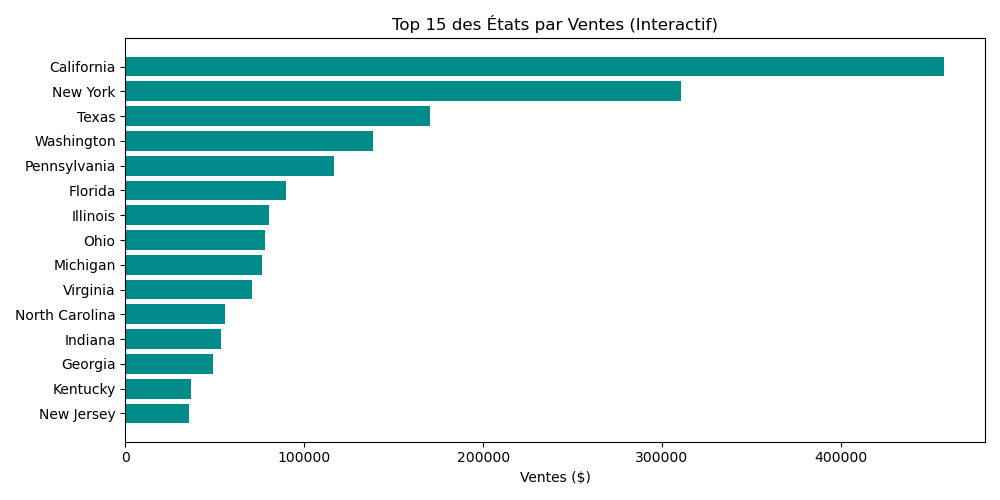

In [3]:
sales_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(10, 5))
plt.barh(sales_state['State'], sales_state['Sales'], color='darkcyan')
plt.gca().invert_yaxis() # Plus grosses ventes en haut
plt.title("Top 15 des États par Ventes (Interactif)")
plt.xlabel("Ventes ($)")
plt.tight_layout()
plt.show()


In [5]:
%matplotlib inline
sns.set_theme(style="darkgrid") # Applique le style élégant de Seaborn


<IPython.core.display.Javascript object>


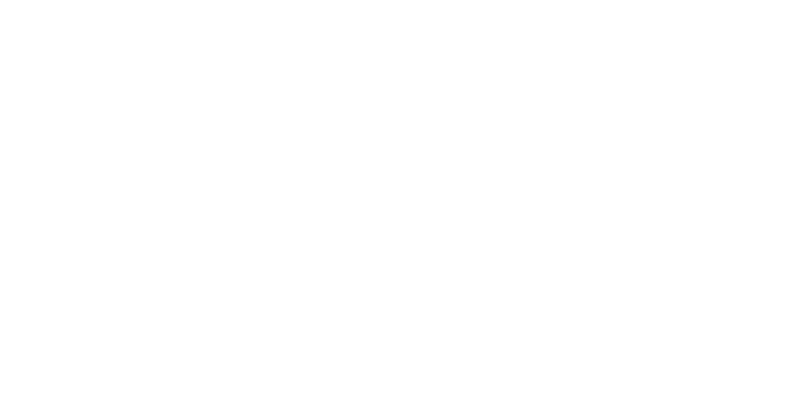

<IPython.core.display.Javascript object>


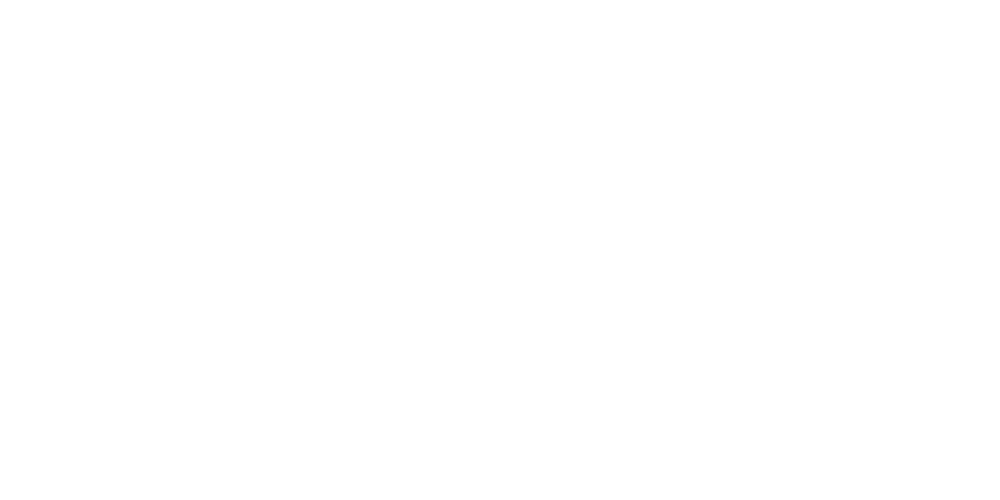

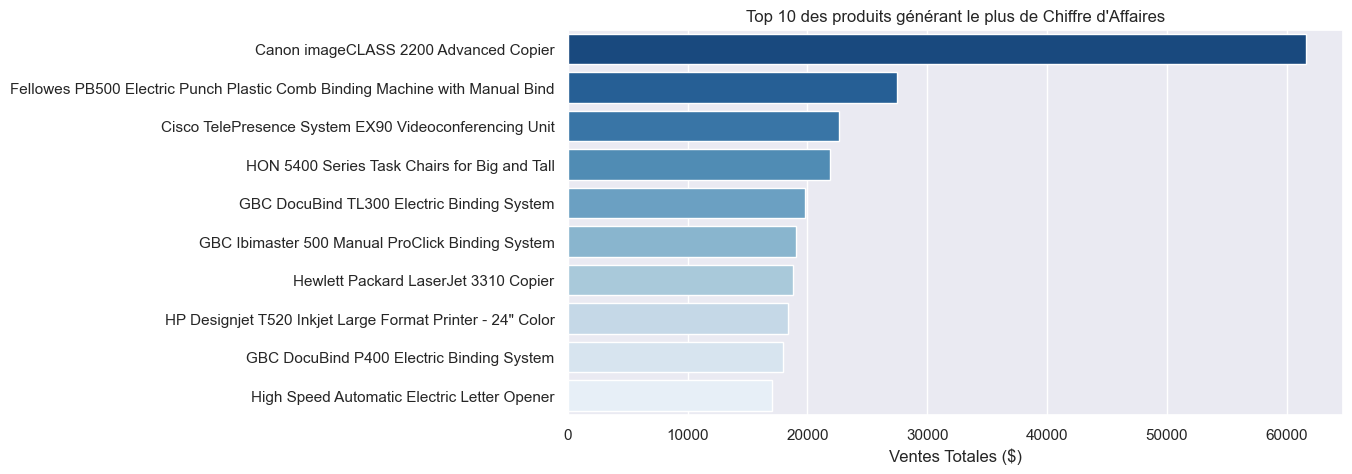

In [6]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette="Blues_r")
plt.title("Top 10 des produits générant le plus de Chiffre d'Affaires")
plt.xlabel("Ventes Totales ($)")
plt.ylabel("") # Supprime le label redondant
plt.show()


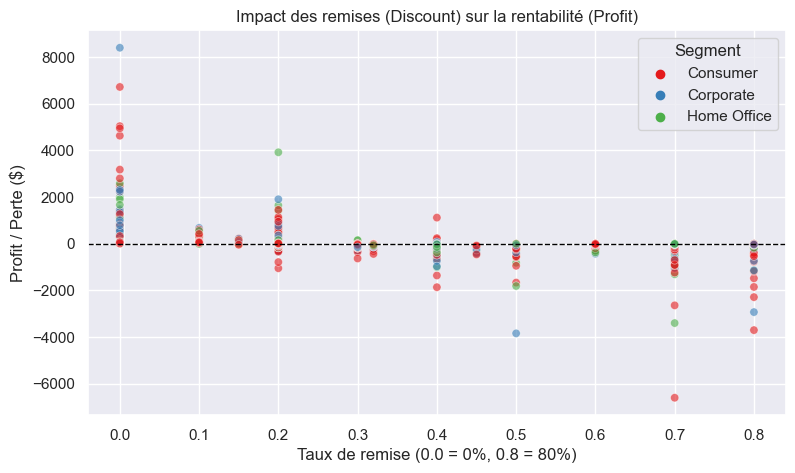

In [7]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.6, hue='Segment', palette="Set1")
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Ligne de profit zéro
plt.title("Impact des remises (Discount) sur la rentabilité (Profit)")
plt.xlabel("Taux de remise (0.0 = 0%, 0.8 = 80%)")
plt.ylabel("Profit / Perte ($)")
plt.show()


 Analyse comparative & Observations (Pour votre cellule Markdown)
📝 Informations extraites des donnéesTendance temporelle : Les ventes affichent une croissance globale constante d'année en année.
Impact Marketing : Le nuage de points révèle une tendance critique : dès que la remise (Discount) dépasse 0.2 (20%), les bénéfices s'effondrent et l'entreprise enregistre de lourdes pertes.

Les remises agressives détruisent la rentabilité.⚖️ Comparaison : Matplotlib vs SeabornMatplotlib :Avantages : Excellent pour le contrôle de bas niveau et l'interactivité technique (zoom, sélection de zones précises via l'interface du notebook).

Inconvénients : Le design par défaut est très brut et demande beaucoup de lignes de code pour être esthétique.Seaborn :Avantages : Graphiques d'une qualité visuelle professionnelle immédiate.

Gestion native et simplifiée des variables catégorielles (comme l'argument hue='Segment').Inconvénients : Moins adapté pour l'interactivité dynamique en temps réel, orienté principalement vers la visualisation statistique statique.Souhaitez-vous que nous ajoutions une carte géographique interactive réelle (avec la bibliothèque Folium) pour afficher la répartition par États, ou préférez-vous passer à un autre outil comme Plotly ?